In [85]:
import numpy as np
#creatre a DNA sequence and calcute the frequency of GC (GC content) 
def calculate_gc_content(sequence, window_size, step):
    """
    Encode une séquence d'ADN en fréquences GC.
    """
    
    sequence = sequence.upper()
    frequencies = []
    for i in range(0, len(sequence) - window_size + 1, step):
        sub_seq = sequence[i : i + window_size]
        gc_count = sub_seq.count('G') + sub_seq.count('C')
        gc_percentage = gc_count / window_size
        frequencies.append(gc_percentage)
    return np.array(frequencies) 
   

# create ADN sequence
dna_test = "ATGC" * 25 + "GCGC" * 25 # Séquence fictive de 200 pb
encoded_data = calculate_gc_content(dna_test, 50, 25)

# find the true output of the sequence
true_output=np.zeros(len(encoded_data))
for i in range(len(encoded_data)):
   if (encoded_data[i] >= 0.75 ):
       true_output[i]= 1
    
print(f"encoded vector is : {encoded_data}")
print(f"true output is : {true_output}")
print(f"this encoded vector contains 7 inputs points that need to be classified into 2 classes : CpG island (1) and not CpG island (0) using perceptron")

encoded vector is : [0.48 0.5  0.52 0.76 1.   1.   1.  ]
true output is : [0. 0. 0. 1. 1. 1. 1.]
this encoded vector contains 7 inputs points that need to be classified into 2 classes : CpG island (1) and not CpG island (0) using perceptron


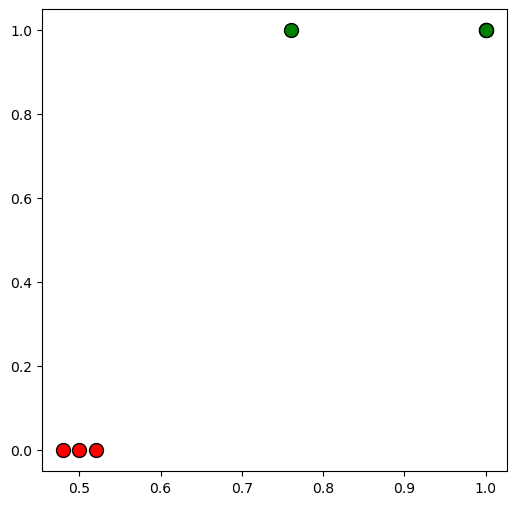

In [87]:
 #representing graphicaly  the encoded vector ( 7 inputs with their true outputs)
import numpy as np
import matplotlib.pylab as plt

X = encoded_data
Y = true_output   

plt.figure(figsize=(6,6))
for i in range(len(Y)):
    plt.scatter(X[i],Y[i], c=('red' if Y[i]==0 else 'green'), s=100, edgecolors='k')
plt.show()

In [89]:
# apply the  perceptron to classify our encoded vector
def perceptron (inputs,output_true,nb_epoch):
    y=np.ones(len(output_true))
    z=np.ones(len(output_true))
    w=np.random.randn()
    bias=np.random.randn()
    alpha=0.1
    classes= np.ones(len(output_true))
    for ep in range (nb_epoch): 
        for i in range (len(output_true)):
            z[i]=np.dot(inputs[i],w) + bias
            y[i]= 1/(1 + np.exp(-z[i]))
            if y [i] != output_true[i]:
                w=w+(alpha*(output_true[i] - y[i])*inputs[i]*(y[i]*(1-y[i])) ) 
                bias= bias+ (alpha*(output_true[i] - y[i])*(y[i]*(1-y[i])) ) 
            if y [i] >= 0.5:
                classes [i]=1
            else: classes [i]=0
    print("epoch number",ep+1)
    print("estimated y is",y)
    print("true y is",Y)
    print("the obtained classes are:",classes)
    print("w=",w)
    print("Z=",z)
    print("bias= ",bias)
    print("The error is equal to:",(output_true-y)**2)
    print("the mean error is equal to:", np.sum ((output_true-y)**2)/len(output_true))



In [91]:
## try many values for the number of epochs 
perceptron (X,Y,1000) 

epoch number 1000
estimated y is [0.24530389 0.26642777 0.28847505 0.61946942 0.86997131 0.87030373
 0.87063386]
true y is [0. 0. 0. 1. 1. 1. 1.]
the obtained classes are: [0. 0. 0. 1. 1. 1. 1.]
w= 5.834629634025714
Z= [-1.12381734 -1.0128229  -0.90280188  0.48729678  1.90070512  1.90364692
  1.90657482]
bias=  -3.9251406963935476
The error is equal to: [0.060174   0.07098376 0.08321785 0.14480352 0.01690746 0.01682112
 0.0167356 ]
the mean error is equal to: 0.05852047374461821


In [99]:
def calculate_gc_count(sequence, window_size, step):
    """
    Encode une séquence d'ADN en fréquences GC.
    """
    
  
    sequence = sequence.upper()
    gc_count_cumulative = []
    for i in range(0, len(sequence) - window_size + 1, step):
        sub_seq = sequence[i : i + window_size]
        gc_count = sub_seq.count('G') + sub_seq.count('C')
        gc_count_cumulative.append(gc_count)
    return np.array(gc_count_cumulative)

# Exemple d'utilisation
dna_test = "ATGC" *25 + "GCGC" * 25# ADN  Sequence 
encoded_data_count = calculate_gc_count(dna_test, 50, 25)
print(f"Vector of CG count is: {encoded_data_count}")

X = encoded_data_count
Y = true_output   



Vector of CG count is: [24 25 26 38 50 50 50]


In [101]:
## try many values for the number of epochs 
perceptron (X,Y,1000) 

epoch number 1000
estimated y is [0.99999996 0.99999998 0.99999999 1.         1.         1.
 1.        ]
true y is [0. 0. 0. 1. 1. 1. 1.]
the obtained classes are: [1. 1. 1. 1. 1. 1. 1.]
w= 0.7386082748214924
Z= [16.92779198 17.66639777 18.40500474 27.26830335 36.13160265 36.13160265
 36.13160265]
bias=  -0.7988110923173414
The error is equal to: [9.99999911e-01 9.99999957e-01 9.99999980e-01 2.06581613e-24
 4.93038066e-32 4.93038066e-32 4.93038066e-32]
the mean error is equal to: 0.4285714068805217
